<a href="https://colab.research.google.com/github/mireillebishay/machine-learning-practice/blob/netflix/Netflix_Kaggle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Imports

In [48]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

Load the Dataset

In [49]:
df = pd.read_csv('/content/drive/MyDrive/Datasets/Netflix.csv')
print("First 5 rows of the DataFrame:")
print(df.head())
print("\nSummary of the DataFrame:")
df.info()
print("\nDescriptive statistics of the DataFrame:")
print(df.describe())

First 5 rows of the DataFrame:
  show_id     type                                      title        director  \
0      s1  TV Show                                         3%             NaN   
1     s10    Movie                                       1920    Vikram Bhatt   
2    s100    Movie                                 3 Heroines  Iman Brotoseno   
3   s1000    Movie  Blue Mountain State: The Rise of Thadland    Lev L. Spiro   
4   s1001  TV Show                             Blue Planet II             NaN   

                                                cast         country  \
0  João Miguel, Bianca Comparato, Michel Gomes, R...          Brazil   
1  Rajneesh Duggal, Adah Sharma, Indraneil Sengup...           India   
2  Reza Rahadian, Bunga Citra Lestari, Tara Basro...       Indonesia   
3  Alan Ritchson, Darin Brooks, James Cade, Rob R...   United States   
4                                 David Attenborough  United Kingdom   

  date_added  release_year rating  duration  \
0 

Preprocessing

In [50]:
print("\nRatings:")
sorted(df["rating"].dropna().unique())


Ratings:


['G',
 'NC-17',
 'NR',
 'PG',
 'PG-13',
 'R',
 'TV-14',
 'TV-G',
 'TV-MA',
 'TV-PG',
 'TV-Y',
 'TV-Y7',
 'TV-Y7-FV',
 'UR']

In [51]:
print("\Genres:")
sorted(df["genres"].dropna().unique())

\Genres:


<>:1: SyntaxWarning: invalid escape sequence '\G'
<>:1: SyntaxWarning: invalid escape sequence '\G'
/tmp/ipython-input-2003457720.py:1: SyntaxWarning: invalid escape sequence '\G'
  print("\Genres:")


['Action & Adventure',
 'Action & Adventure, Anime Features, Children & Family Movies',
 'Action & Adventure, Anime Features, Classic Movies',
 'Action & Adventure, Anime Features, Horror Movies',
 'Action & Adventure, Anime Features, International Movies',
 'Action & Adventure, Anime Features, Sci-Fi & Fantasy',
 'Action & Adventure, Children & Family Movies',
 'Action & Adventure, Children & Family Movies, Classic Movies',
 'Action & Adventure, Children & Family Movies, Comedies',
 'Action & Adventure, Children & Family Movies, Dramas',
 'Action & Adventure, Children & Family Movies, Independent Movies',
 'Action & Adventure, Children & Family Movies, Sci-Fi & Fantasy',
 'Action & Adventure, Classic Movies',
 'Action & Adventure, Classic Movies, Comedies',
 'Action & Adventure, Classic Movies, Cult Movies',
 'Action & Adventure, Classic Movies, Dramas',
 'Action & Adventure, Classic Movies, International Movies',
 'Action & Adventure, Classic Movies, Sci-Fi & Fantasy',
 'Action & Adv

In [52]:
# 1) Keep only Movies because duration is "minutes" for Movies but "seasons" for TV Shows
df = df[df["type"] == "Movie"].copy()

# 2) Drop rows where rating is missing
df = df.dropna(subset=["rating"])

# 3) Map content ratings to an ordinal numeric scale
rating_map = {
    "TV-Y": 0,
    "TV-Y7": 1,
    "TV-Y7-FV": 1,
    "TV-G": 2,
    "G": 2,
    "TV-PG": 3,
    "PG": 3,
    "TV-14": 4,
    "PG-13": 5,
    "R": 6,
    "NC-17": 7,
    "NR": 4,
    "UR": 4
}

# 4) Convert the rating column to numbers using the map above
df["rating_encoded"] = df["rating"].map(rating_map)

# 5) Drop any rows that failed to map
df = df.dropna(subset=["rating_encoded"])

# 6) Show which rating labels exist after filtering to movies
print("Rating value counts (movies only):")
print(df["rating"].value_counts())

# 7) Identify any rating labels present in the data but missing from rating_map
unique_ratings = set(df["rating"].unique())
unmapped_ratings = sorted(unique_ratings - set(rating_map.keys()))
print("\nUnmapped rating labels:", unmapped_ratings)

# 8) Ensure no NaNs exist in rating_encoded
assert df["rating_encoded"].isna().sum() == 0, "Some ratings were not encoded properly!"

# 9) Split multi-genre strings into a list of genre tags per movie
df["genres_list"] = df["genres"].str.split(", ")

# 10) Multi-hot encode genres
mlb = MultiLabelBinarizer()
genres_matrix = mlb.fit_transform(df["genres_list"])

# 11) Turn the encoded genre matrix into a DataFrame with readable column names
genres_df = pd.DataFrame(genres_matrix, columns=mlb.classes_, index=df.index)

# 12) Remove rare genres to reduce noise
min_count = 20
genre_counts = genres_df.sum().sort_values(ascending=False)
keep_genres = genre_counts[genre_counts >= min_count].index
genres_df = genres_df[keep_genres]

# 13) Build the final feature table for clustering
features = pd.concat([df[["duration", "rating_encoded"]], genres_df], axis=1)

# 14) Confirm feature matrix size (rows = movies, columns = features)
print("\nFeatures shape (rows, columns):", features.shape)

# 15) Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# 16) X_scaled is now ready to be passed to KMeans
print("Scaled feature matrix shape:", X_scaled.shape)


Rating value counts (movies only):
rating
TV-14       1272
R            663
TV-PG        505
PG-13        386
PG           247
TV-Y         117
TV-G         111
TV-Y7         95
NR            79
G             39
TV-Y7-FV       5
UR             5
NC-17          3
Name: count, dtype: int64

Unmapped rating labels: []

Features shape (rows, columns): (3527, 22)
Scaled feature matrix shape: (3527, 22)


Pick K using Elbow + Silhouette

    k       inertia  silhouette
0   2  70509.643609    0.143837
1   3  66352.474044    0.131457
2   4  62203.357274    0.169472
3   5  58206.774122    0.200352
4   6  54529.320498    0.196526
5   7  51035.019396    0.216111
6   8  47593.438799    0.212056
7   9  43704.770251    0.257494
8  10  41366.364249    0.272530


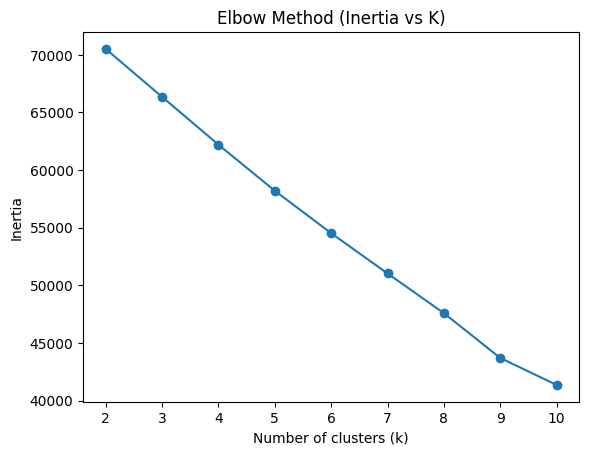

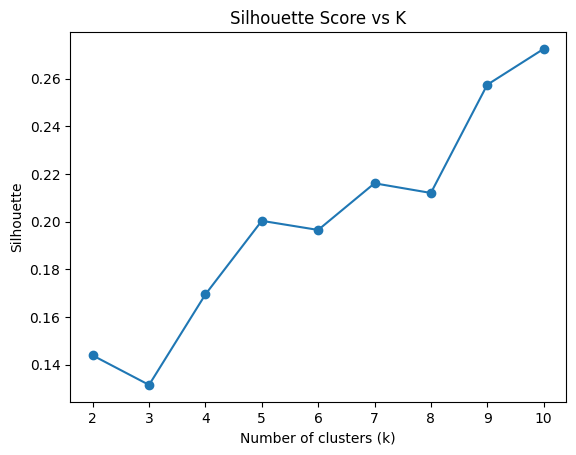

In [53]:
# Try a range of K values
k_values = range(2, 11)

inertias = []
silhouettes = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

results = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette": silhouettes
})

print(results)

# Plot Elbow (inertia)
plt.figure()
plt.plot(results["k"], results["inertia"], marker="o")
plt.title("Elbow Method (Inertia vs K)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.show()

# Plot Silhouette
plt.figure()
plt.plot(results["k"], results["silhouette"], marker="o")
plt.title("Silhouette Score vs K")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette")
plt.show()

Fit KMeans to K = 6 (Based on the results of the previous step)

In [54]:
best_k = 6

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

cluster_names = {
    0: "Documentaries & Non-Fiction",
    1: "International Dramas",
    2: "Kids & Family Movies",
    3: "Cult & Classic Movies",
    4: "Thrillers & Horror",
    5: "Romantic & Feel-Good Movies"
}

df["cluster_name"] = df["cluster"].map(cluster_names)

df[["title", "duration", "rating", "cluster", "cluster_name"]].head()

,title,duration,rating,cluster,cluster_name
2,3 Heroines,124,TV-PG,1,International Dramas
3,Blue Mountain State: The Rise of Thadland,90,R,1,International Dramas
5,Blue Ruin,90,R,4,Thrillers & Horror
6,Blue Streak,94,PG-13,1,International Dramas
7,Blue Valentine,112,R,5,Romantic & Feel-Good Movies


Interpret Clusters

In [55]:
# Basic summary per cluster
cluster_summary = df.groupby("cluster_name").agg(
    n_titles=("title", "count"),
    avg_duration=("duration", "mean"),
    avg_rating=("rating_encoded", "mean"),
    min_year=("release_year", "min"),
    max_year=("release_year", "max")
).sort_values("n_titles", ascending=False)

cluster_summary

# Top genres per cluster
cluster_genres = pd.concat([df["cluster"], genres_df], axis=1).groupby("cluster").mean()

top_genres_per_cluster = {
    c: cluster_genres.loc[c].sort_values(ascending=False).head(8)
    for c in cluster_genres.index
}

for c, top in top_genres_per_cluster.items():
    name = cluster_names.get(c, f"Cluster {c}")
    print(f"\nCluster {c} ({name}) top genres:")
    print(top)

for c in sorted(df["cluster"].unique()):
    name = cluster_names.get(c, f"Cluster {c}")
    print(f"\nCluster {c} ({name}) examples:")
    display(df[df["cluster"] == c][["title", "duration", "rating", "genres"]].head(10))


Cluster 0 (Documentaries & Non-Fiction) top genres:
Documentaries           0.842735
International Movies    0.294017
Sports Movies           0.100855
Music & Musicals        0.088889
Stand-Up Comedy         0.082051
Movies                  0.071795
Faith & Spirituality    0.018803
Classic Movies          0.017094
Name: 0, dtype: float64

Cluster 1 (International Dramas) top genres:
Dramas                  0.619988
International Movies    0.556447
Comedies                0.394818
Action & Adventure      0.295497
Independent Movies      0.178902
Music & Musicals        0.077730
Sci-Fi & Fantasy        0.066626
Classic Movies          0.035163
Name: 1, dtype: float64

Cluster 2 (Kids & Family Movies) top genres:
Children & Family Movies    0.998
Comedies                    0.436
Dramas                      0.124
Music & Musicals            0.054
Sci-Fi & Fantasy            0.036
International Movies        0.030
Sports Movies               0.030
Action & Adventure          0.028
Name: 2

,title,duration,rating,genres
11,BNK48: Girls Don't Cry,108,TV-14,"Documentaries, International Movies, Music & M..."
24,3 Seconds Divorce,53,TV-PG,"Documentaries, Faith & Spirituality"
25,Bobby Robson: More Than a Manager,99,TV-14,"Documentaries, International Movies, Sports Mo..."
26,Bobby Sands: 66 Days,106,TV-14,Documentaries
42,Bombshell: The Hedy Lamarr Story,89,TV-14,Documentaries
63,Born in Gaza,70,TV-14,"Documentaries, International Movies"
64,Born in Syria,87,TV-14,"Documentaries, International Movies"
65,Born Racer,89,R,"Documentaries, Sports Movies"
67,Born to Be Free,74,TV-14,"Documentaries, International Movies"
89,Brave Blue World: Racing to Solve Our Water Cr...,51,TV-PG,"Documentaries, International Movies"



Cluster 1 (International Dramas) examples:


,title,duration,rating,genres
2,3 Heroines,124,TV-PG,"Dramas, International Movies, Sports Movies"
3,Blue Mountain State: The Rise of Thadland,90,R,Comedies
6,Blue Streak,94,PG-13,"Action & Adventure, Comedies"
13,3 Idiots,164,PG-13,"Comedies, Dramas, International Movies"
21,Bobby,168,TV-14,"Classic Movies, Dramas, International Movies"
22,Bobby Jasoos,116,TV-14,"Comedies, Dramas, International Movies"
28,Bodyguard,130,TV-14,"Action & Adventure, Comedies, International Mo..."
29,Bogda,161,TV-PG,"Dramas, International Movies"
33,Bokeh,92,TV-14,"Dramas, Independent Movies, Sci-Fi & Fantasy"
46,30 Days of Luxury,91,TV-14,"Comedies, International Movies"



Cluster 2 (Kids & Family Movies) examples:


...

,title,duration,rating,genres
226,Candyman,99,R,"Cult Movies, Horror Movies"
254,Carrie,98,R,"Classic Movies, Cult Movies, Horror Movies"
322,Chasing Amy,113,R,"Comedies, Cult Movies, Dramas"
371,Child's Play,87,R,"Cult Movies, Horror Movies"
474,Cloud Atlas,172,R,"Action & Adventure, Cult Movies, Dramas"
734,A Clockwork Orange,137,R,"Classic Movies, Cult Movies, Dramas"
865,Disco Dancer,134,TV-14,"Cult Movies, Dramas, International Movies"
1080,Elaan,143,TV-14,"Action & Adventure, Cult Movies, International..."
1145,Esperando La Carroza,95,NR,"Comedies, Cult Movies, International Movies"
1235,A Night at the Roxbury,82,PG-13,"Comedies, Cult Movies"



Cluster 4 (Thrillers & Horror) examples:


,title,duration,rating,genres
5,Blue Ruin,90,R,"Independent Movies, Thrillers"
110,Brick,110,R,"Independent Movies, Thrillers"
113,40 Sticks,93,TV-14,"International Movies, Thrillers"
127,Brooklyn's Finest,133,R,"Dramas, Thrillers"
152,Bullet Head,94,R,"International Movies, Thrillers"
178,Bypass Road,135,TV-14,"International Movies, Thrillers"
182,Cabin Fever,98,R,"Horror Movies, Thrillers"
256,Carriers,85,PG-13,"Horror Movies, Sci-Fi & Fantasy, Thrillers"
261,Case 39,111,R,"Horror Movies, Thrillers"
350,Chernobyl Diaries,88,R,"Horror Movies, Thrillers"



Cluster 5 (Romantic & Feel-Good Movies) examples:


,title,duration,rating,genres
7,Blue Valentine,112,R,"Dramas, Independent Movies, Romantic Movies"
8,BluffMaster!,129,TV-14,"Comedies, International Movies, Romantic Movies"
99,Break Up 100,105,TV-14,"Comedies, International Movies, Romantic Movies"
111,Bride For Rent,110,TV-PG,"Comedies, International Movies, Romantic Movies"
160,Burlesque,119,PG-13,"Dramas, Romantic Movies"
172,Butterfield 8,108,TV-14,"Classic Movies, Dramas, Romantic Movies"
175,By the Sea,122,R,"Dramas, Romantic Movies"
218,Can't Hardly Wait,101,PG-13,"Comedies, Romantic Movies"
221,Candy Jar,93,TV-14,"Children & Family Movies, Dramas, Romantic Movies"
235,5 to 7,97,R,"Comedies, Dramas, Romantic Movies"


Visualize Clusters

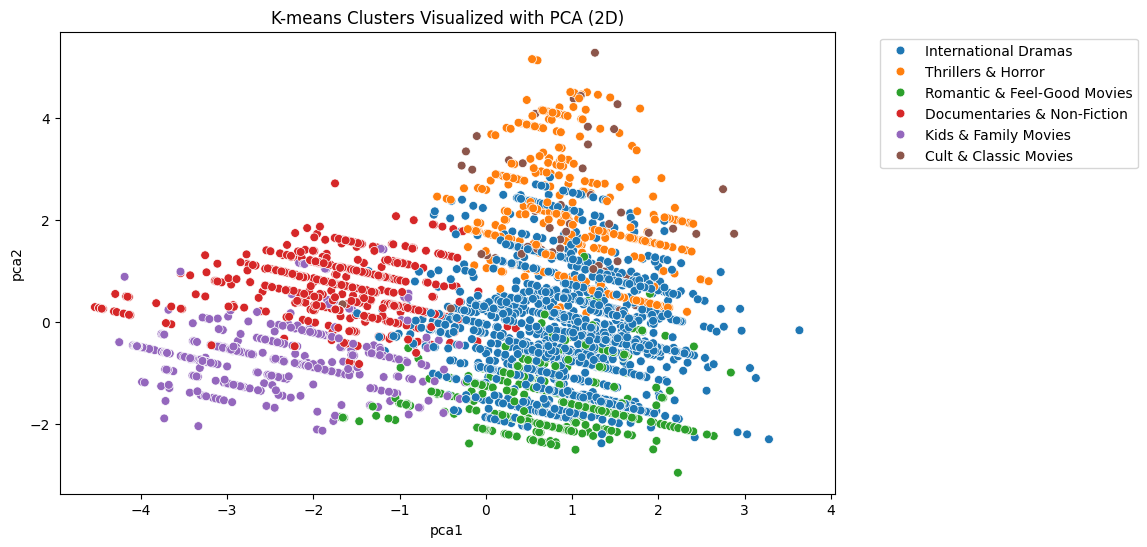

In [56]:
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

plot_df = pd.DataFrame({
    "pca1": X_2d[:, 0],
    "pca2": X_2d[:, 1],
    "cluster": df["cluster"].values,
    "cluster_name": df["cluster_name"].values
})

plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_df, x="pca1", y="pca2", hue="cluster_name", s=40)
plt.title("K-means Clusters Visualized with PCA (2D)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()